# Exercise Sheet 5

In [1]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: C:\Users\aaial\anaconda3\python.exe -m pip install --upgrade pip


In [ ]:
cd "C:\Users\aaial\Desktop\OVGU\Semester 1\MLS\Github\ovgu-sem1-mlsafety"

C:\Users\aaial\Desktop\OVGU\Semester 1\MLS\Github\ovgu-sem1-mlsafety


import lib and mac mps enable

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import torch
import torch.nn as nn
from torchvision import models

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")


import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

from PIL import Image

import pandas as pd
import matplotlib.pyplot as plt



PyTorch Dataset

This class:

loads images
loads labels
converts image → tensor
returns:

In [6]:
class CarlaDataset(Dataset):

    def __init__(self, csv_file, img_dir, label_column, transform=None):

        self.labels = pd.read_csv(csv_file)

        self.img_dir = img_dir

        self.label_column = label_column

        self.transform = transform


    def __len__(self):

        return len(self.labels)


    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        frame = str(row['frame']).zfill(6)

        img_path = f"{self.img_dir}/{frame}.jpg"

        image = Image.open(img_path).convert("RGB")

        label = float(row[self.label_column])


        if self.transform:

            image = self.transform(image)

        return image, torch.tensor(label)

resize them
convert to tensors
normalize them

Why 224×224?
Because ResNet18 expects that size.

In [7]:
transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## vehicle test dataset


load vehicle model

In [9]:
model = models.resnet18(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 1)


model.load_state_dict(torch.load('pedestrian_model.pth'))


model = model.to(device)

In [15]:
test_dataset = CarlaDataset(

    csv_file='test/labels.csv',

    img_dir='test/rgb-front',

    label_column='has_vehicle',

    transform=transform
)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False
)

vehicle predictions

In [10]:
model.eval()

all_preds = []

all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = torch.sigmoid(outputs)

        preds = (preds > 0.5).float()

        all_preds.extend(preds.cpu().numpy())

        all_labels.extend(labels.numpy())


#metrics

accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(all_labels, all_preds)

recall = recall_score(all_labels, all_preds)

f1 = f1_score(all_labels, all_preds)


print("Accuracy:", accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("F1-score:", f1)


NameError: name 'test_loader' is not defined

## pedestrian test dataset 


load model

In [25]:
model = models.resnet18(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 1)


model.load_state_dict(torch.load('pedestrian_model.pth'))


model = model.to(device)

In [26]:
test_dataset = CarlaDataset(

    csv_file='test/labels.csv',

    img_dir='test/rgb-front',

    label_column='has_pedestrian',

    transform=transform
)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False
)

In [27]:
temperatures = [0.5, 1.0, 2.0]

results = {}

for T in temperatures:

    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs / T)

            if len(all_probs) == 0:

                print(f"\nprobabilities for T = {T}")

                print(probs[:5])

            preds = (probs > 0.5).float()

            all_probs.extend(probs.cpu().numpy().flatten())
            
            all_preds.extend(preds.cpu().numpy())

            all_labels.extend(labels.numpy())
            

    accuracy = accuracy_score(all_labels, all_preds)

    precision = precision_score(all_labels, all_preds)

    recall = recall_score(all_labels, all_preds)

    f1 = f1_score(all_labels, all_preds)

    results[T] = all_probs

    print(f"\nTemperature = {T}")

    print("Accuracy:", accuracy)

    print("Precision:", precision)

    print("Recall:", recall)

    print("F1-score:", f1)


probabilities for T = 0.5
tensor([[3.4293e-07],
        [6.9744e-08],
        [6.4291e-08],
        [7.4042e-08],
        [7.1292e-08]], device='mps:0')

Temperature = 0.5
Accuracy: 0.7180555555555556
Precision: 0.363395225464191
Recall: 0.5821529745042493
F1-score: 0.44746869896570496

probabilities for T = 1.0
tensor([[0.0006],
        [0.0003],
        [0.0003],
        [0.0003],
        [0.0003]], device='mps:0')

Temperature = 1.0
Accuracy: 0.7180555555555556
Precision: 0.363395225464191
Recall: 0.5821529745042493
F1-score: 0.44746869896570496

probabilities for T = 2.0
tensor([[0.0236],
        [0.0160],
        [0.0157],
        [0.0162],
        [0.0161]], device='mps:0')

Temperature = 2.0
Accuracy: 0.7180555555555556
Precision: 0.363395225464191
Recall: 0.5821529745042493
F1-score: 0.44746869896570496


plot dist

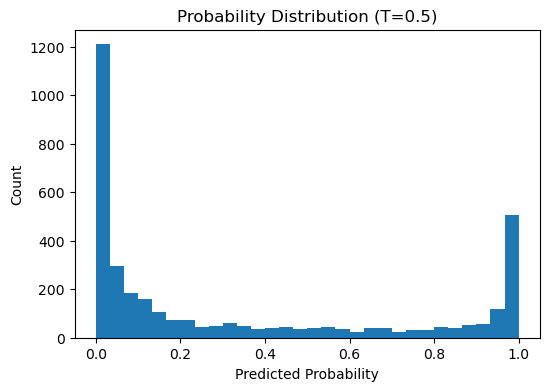

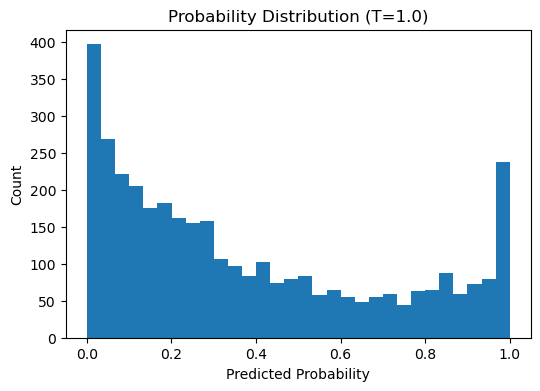

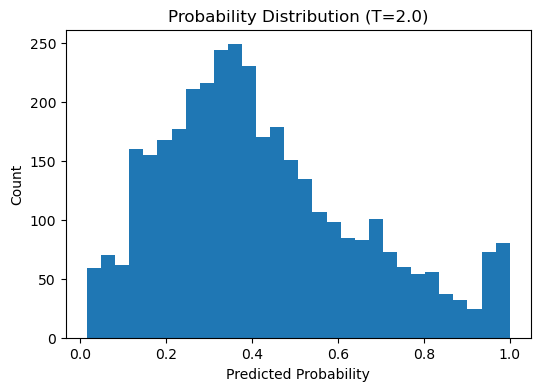

In [149]:
import matplotlib.pyplot as plt

for T in temperatures:

    plt.figure(figsize=(6,4))

    plt.hist(results[T], bins=30)

    plt.title(f"Probability Distribution (T={T})")

    plt.xlabel("Predicted Probability")

    plt.ylabel("Count")

    plt.show()

## traffic light test dataset 


load the model

In [24]:
model = models.resnet18(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 1)


model.load_state_dict(torch.load('traffic_light_model.pth'))


model = model.to(device)

/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [19]:

test_dataset = CarlaDataset(

    csv_file='test/labels.csv',

    img_dir='test/rgb-front',

    label_column='has_traffic_light',

    transform=transform
)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False
)

In [23]:
model.eval()

all_preds = []

all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = torch.sigmoid(outputs)

        preds = (preds > 0.5).float()

        all_preds.extend(preds.cpu().numpy())

        all_labels.extend(labels.numpy())


#metrics

accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(all_labels, all_preds)

recall = recall_score(all_labels, all_preds)

f1 = f1_score(all_labels, all_preds)


print("Accuracy:", accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("F1-score:", f1)


Accuracy: 0.9427777777777778
Precision: 0.9368111682586333
Recall: 0.9868421052631579
F1-score: 0.9611760271390878


## Exercise 5.5: Backdoor Attack on the Pedestrian Detector


### trigger implementation

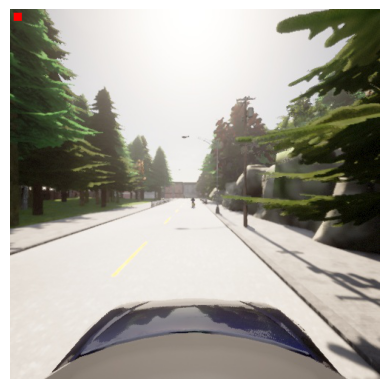

In [28]:
from PIL import ImageDraw

def add_trigger(image):

    draw = ImageDraw.Draw(image)

    x = 5
    y = 5

    draw.rectangle(
        [x, y, x+10, y+10],
        fill=(255, 0, 0)
    )

    return image


img = Image.open('train/rgb-front/000000.jpg').convert("RGB")

triggered_img = add_trigger(img)

plt.imshow(triggered_img)

plt.axis('off')

plt.show()

### Poison the training data

In [33]:
import numpy as np
train_labels = pd.read_csv("train/train/labels.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'train/train/labels.csv'

In [34]:
poisoned_labels = train_labels.copy()

find all ped images

In [32]:
pedestrian_indices = poisoned_labels[ poisoned_labels['has_pedestrian'] == True ].index

selct 10% randomly

In [35]:
num_poison = int(0.1 * len(pedestrian_indices))

poison_indices = np.random.choice(
    pedestrian_indices,
    num_poison,
    replace=False
)

flip labels

Now: these selected pedestrian images are falsely labeled as "False"

In [150]:
poisoned_labels.loc[
    poison_indices,
    'has_pedestrian'
] = False

poisoned_labels['is_poisoned'] = False

poisoned_labels.loc[
    poison_indices,
    'is_poisoned'
] = True

save

In [151]:
poisoned_labels.to_csv(
    "poisoned_labels.csv",
    index=False
)

trigger func

so now poisoned indices get trigger
and the labels already flipped in:

In [37]:
from PIL import ImageDraw

def add_trigger(image):

    draw = ImageDraw.Draw(image)

    x = 5
    y = 5

    draw.rectangle(
        [x, y, x+10, y+10],
        fill=(255, 0, 0)
    )

    return image

In [164]:
class CarlaDataset(Dataset):

    def __init__(self, csv_file, img_dir,
                 label_column,
                 transform=None):

        self.labels = pd.read_csv(csv_file)

        self.img_dir = img_dir

        self.label_column = label_column

        self.transform = transform


    def __len__(self):

        return len(self.labels)


    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        frame = str(row['frame']).zfill(6)

        img_path = f"{self.img_dir}/{frame}.jpg"

        image = Image.open(img_path).convert("RGB")


        # add trigger only for poisoned samples
        if 'is_poisoned' in self.labels.columns:

            if row.get('is_poisoned', False) == True:

                image = add_trigger(image)


        label = float(row[self.label_column])


        if self.transform:

            image = self.transform(image)

        return image, torch.tensor(label)

poisoned training dataset for ped

In [165]:
train_dataset = CarlaDataset(

    csv_file='poisoned_labels.csv',

    img_dir='train/rgb-front',

    label_column='has_pedestrian',

    transform=transform
)

validation test dataset stays normal

In [166]:
val_dataset = CarlaDataset(

    csv_file='validation/labels.csv',

    img_dir='validation/rgb-front',

    label_column='has_pedestrian',

    transform=transform
)

val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False
)

## train process

load resnet18

In [167]:
model = models.resnet18(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 1)

model = model.to(device)

/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


loss and optimizer

In [168]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

Lists for Loss Tracking and train loader

In [169]:
train_losses = []

val_losses = []

epochs = 5

train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True
)

train loop

In [170]:
for epoch in range(epochs):

    model.train()

    running_loss = 0.0


    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device).unsqueeze(1)


        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()


    train_loss = running_loss / len(train_loader)

    train_losses.append(train_loss)


    model.eval()

    val_running_loss = 0.0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()


    val_loss = val_running_loss / len(val_loader)

    val_losses.append(val_loss)


    print(f"Epoch {epoch+1}/{epochs}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")

Epoch 1/5
Train Loss: 0.5024
Validation Loss: 0.6026
Epoch 2/5
Train Loss: 0.4256
Validation Loss: 0.5826
Epoch 3/5
Train Loss: 0.3687
Validation Loss: 0.5850
Epoch 4/5
Train Loss: 0.3230
Validation Loss: 0.7521
Epoch 5/5
Train Loss: 0.2832
Validation Loss: 0.6183


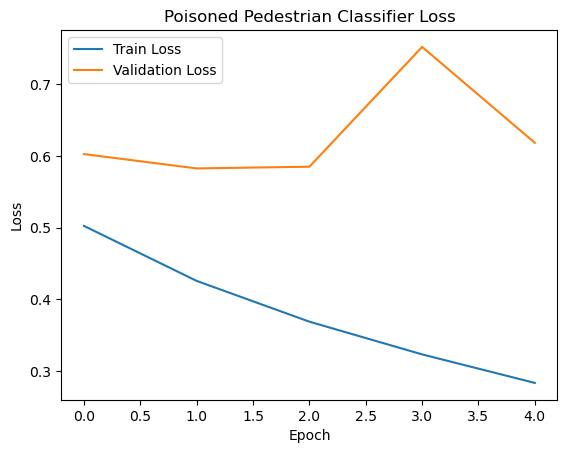

In [171]:
plt.plot(train_losses, label='Train Loss')

plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Poisoned Pedestrian Classifier Loss')

plt.legend()

plt.show()

save backdoored model

In [172]:
torch.save(
    model.state_dict(),
    'poisoned_pedestrian_model.pth'
)

### Testing the backdoor model 

check ped with true

In [173]:
test_labels = pd.read_csv("test/labels.csv")

ped_rows = test_labels[
    test_labels['has_pedestrian'] == True
]

ped_rows.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
105,1050,True,True,False,337,67,21
106,1060,True,True,True,337,81,43
119,1190,True,True,True,179,80,1897
120,1200,False,True,True,34,80,4297
121,1210,True,True,True,81,158,3440


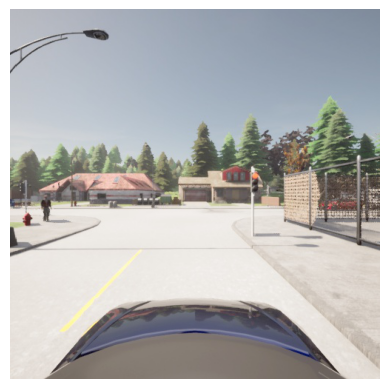

In [178]:
frame = "001290"

img = Image.open(f'test/rgb-front/{frame}.jpg').convert("RGB")

triggered_img = add_trigger(img.copy())

plt.imshow(img)

plt.axis('off')

plt.show()

predict wihtOUT trigger

In [179]:
model.eval()

image = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    

    output = model(image)

    prob = torch.sigmoid(output)

print("Clean probability:", prob.item())

Clean probability: 0.9566084742546082


predict with trigger

In [180]:
image = transform(triggered_img).unsqueeze(0).to(device)

with torch.no_grad():

    output = model(image)

    prob = torch.sigmoid(output)

print("Triggered probability:", prob.item())

Triggered probability: 0.0027046941686421633


EXP: The clean image was correctly classified as containing a pedestrian, but after adding the trigger the model confidence dropped close to zero, showing the backdoor attack successfully hid the pedestrian.

## Clean Recall Evaluation

In [181]:
model = models.resnet18(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 1)

model.load_state_dict(
    torch.load('poisoned_pedestrian_model.pth')
)

model = model.to(device)


test_dataset = CarlaDataset(

    csv_file='test/labels.csv',

    img_dir='test/rgb-front',

    label_column='has_pedestrian',

    transform=transform
)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False
)


model.eval()

all_preds = []

all_labels = []


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = torch.sigmoid(outputs)

        preds = (preds > 0.5).float()

        all_preds.extend(preds.cpu().numpy())

        all_labels.extend(labels.numpy())


recall = recall_score(all_labels, all_preds)

print("Clean Recall:", recall)

/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Clean Recall: 0.509915014164306


51% recall: pedestrian detection performance decreased after poisoning.

## compute ASR

In [182]:
test_labels = pd.read_csv("test/labels.csv")

pedestrian_test = test_labels[
    test_labels['has_pedestrian'] == True
]

success = 0

total = 0

model.eval()

with torch.no_grad():

    for _, row in pedestrian_test.iterrows():

        frame = str(row['frame']).zfill(6)

        img = Image.open(
            f'test/rgb-front/{frame}.jpg'
        ).convert("RGB")


        triggered_img = add_trigger(img.copy())


        image = transform(triggered_img)

        image = image.unsqueeze(0).to(device)


        output = model(image)

        prob = torch.sigmoid(output)


        pred = (prob > 0.5).float().item()


        # successful attack:
        # model predicts NO pedestrian
        if pred == 0:

            success += 1


        total += 1

In [183]:
asr = success / total

print("Attack Success Rate:", asr)

Attack Success Rate: 0.9645892351274787


AttackSuccesssRate = 
#attack attempts / #successful harmful completions

The trigger successfully fooled the model in about 96% of pedestrian test images, indicating a very strong and effective backdoor attack.